In [1]:
!unzip "archive (5).zip"

Archive:  archive (5).zip
  inflating: creditcard.csv          


In [2]:
import pandas as pd

# Load the csv file
df = pd.read_csv('creditcard.csv')

# Look at the first few rows and column names
print("Columns in dataset:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Columns in dataset: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
import nltk
import re
import collections

# 1. Download the 'gutenberg' text files
nltk.download('gutenberg')
from nltk.corpus import gutenberg

# 2. Combine classic texts to create a vocabulary base
raw_text = gutenberg.raw('shakespeare-caesar.txt') + " " + gutenberg.raw('melville-moby_dick.txt')

# 3. Clean and process into lower-case words
words = re.findall(r'\b[a-z]+\b', raw_text.lower())
word_counts = collections.Counter(words)

# 4. Print results to verify
print(f"Total words loaded: {len(words)}")
print(f"Unique words in vocabulary: {len(word_counts)}")
print("Sample common words:", word_counts.most_common(5))

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.


Total words loaded: 239161
Unique words in vocabulary: 18436
Sample common words: [('the', 15010), ('and', 7057), ('of', 6963), ('to', 5071), ('a', 5003)]


In [4]:
def get_edits_1(word):
    """Generates all possible edits that are exactly 1 letter away from 'word'."""
    letters    = 'abcdefghijklmnopqrstuvwxyz'
    splits     = [(word[:i], word[i:]) for i in range(len(word) + 1)]
    deletes    = [L + R[1:] for L, R in splits if R]
    swaps      = [L + R[1] + R[0] + R[2:] for L, R in splits if len(R) > 1]
    replaces   = [L + c + R[1:] for L, R in splits if R for c in letters]
    inserts    = [L + c + R for L, R in splits for c in letters]
    return set(deletes + swaps + replaces + inserts)

def get_edits_2(word):
    """Generates all possible edits that are exactly 2 letters away."""
    return set(e2 for e1 in get_edits_1(word) for e2 in get_edits_1(e1))

def autocorrect(word):
    """Suggests the closest valid vocabulary words, highest frequency first."""
    word = word.lower()

    # If the word is already spelled perfectly, return it
    if word in word_counts:
        return [word]

    # Look for candidates at 1-edit distance, then 2-edit distance, or fall back to the word itself
    candidates = (get_edits_1(word) & set(word_counts.keys())) or \
                 (get_edits_2(word) & set(word_counts.keys())) or \
                 [word]

    # Sort candidates by how common they are in our book data
    suggestions = sorted(candidates, key=lambda w: word_counts[w], reverse=True)
    return suggestions[:3]  # Return top 3 suggestions

# Test the autocorrect function
print("Correction for 'freind':", autocorrect("freind"))
print("Correction for 'shw':", autocorrect("shw"))
print("Correction for 'thnk':", autocorrect("thnk"))

Correction for 'freind': ['friend']
Correction for 'shw': ['she', 'saw', 'show']
Correction for 'thnk': ['think', 'thank', 'tink']


In [5]:
def autocomplete(prefix):
    """Finds words in the vocabulary that start with the given prefix, sorted by popularity."""
    prefix = prefix.lower()

    # Filter the vocabulary keys to find words starting with the prefix
    candidates = [word for word in word_counts.keys() if word.startswith(prefix)]

    # Sort candidates based on their frequency count (highest frequency first)
    suggestions = sorted(candidates, key=lambda w: word_counts[w], reverse=True)

    return suggestions[:5]  # Return top 5 autocomplete matches

# Test the autocomplete function
print("Autocomplete for 'th':", autocomplete("th"))
print("Autocomplete for 'cle':", autocomplete("cle"))
print("Autocomplete for 'kin':", autocomplete("kin"))
print("Autocomplete for 'ha':", autocomplete("ha"))

Autocomplete for 'th': ['the', 'that', 'this', 'there', 'then']
Autocomplete for 'cle': ['clear', 'clean', 'clearing', 'cleared', 'clenched']
Autocomplete for 'kin': ['king', 'kind', 'kings', 'kindred', 'kinde']
Autocomplete for 'ha': ['had', 'have', 'has', 'hand', 'haue']


Metrics Evaluated:
- Average Autocorrect Latency: 0.001148 seconds
- Average Autocomplete Latency: 0.002099 seconds



/tmp/ipykernel_4803/240543215.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_freqs, y=word_labels, palette="viridis")


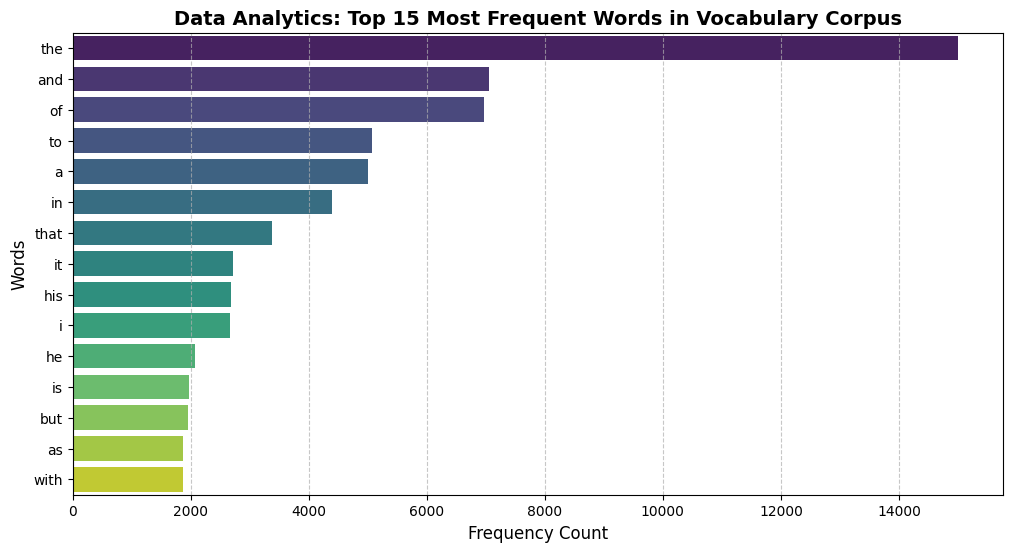

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import time

# 1. Measure Execution Performance (Analytics Metric)
start_time = time.time()
for _ in range(100):
    autocorrect("freind")
autocorrect_time = (time.time() - start_time) / 100

start_time = time.time()
for _ in range(100):
    autocomplete("th")
autocomplete_time = (time.time() - start_time) / 100

print(f"Metrics Evaluated:")
print(f"- Average Autocorrect Latency: {autocorrect_time:.6f} seconds")
print(f"- Average Autocomplete Latency: {autocomplete_time:.6f} seconds\n")

# 2. Visualization: Plot the Top 15 Most Common Words in the Dataset
top_words = word_counts.most_common(15)
word_labels = [item[0] for item in top_words]
word_freqs = [item[1] for item in top_words]

plt.figure(figsize=(12, 6))
sns.barplot(x=word_freqs, y=word_labels, palette="viridis")
plt.title("Data Analytics: Top 15 Most Frequent Words in Vocabulary Corpus", fontsize=14, fontweight='bold')
plt.xlabel("Frequency Count", fontsize=12)
plt.ylabel("Words", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Display the plot
plt.show()